# Model Evaluation - Telco Churn

Evidence behind the model shipped in `models/churn_model.pkl`.

Covers the overfitting problem in the original model, the three-way split,
model comparison, threshold selection, the fairness audit, and SHAP explanations.

Run with the dev image so xgboost and shap are available:

```bash
docker build -f Dockerfile.dev -t churn-dev .
docker run --rm -p 8888:8888 -v "${PWD}:/app" churn-dev \
  jupyter notebook --ip=0.0.0.0 --allow-root --no-browser
```

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_curve, roc_curve,
    precision_score, recall_score, f1_score, roc_auc_score,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

model = joblib.load("../models/churn_model.pkl")
meta = json.load(open("../models/model_metadata.json"))
THRESHOLD = meta["threshold"]
print(f"Model: {meta['model_type']} | threshold: {THRESHOLD} | trained: {meta['trained_on']}")

Model: RandomForest | threshold: 0.46 | trained: 2026-08-10


## 1. Reproduce the split

The same 60/20/20 split as `src/train.py`. The test set is scored once, at the
end - every tuning decision was made on validation.

In [2]:
df = pd.read_csv("../data/raw/telco_churn.csv").drop(columns=["customerID"])
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)

y = df["Churn"].map({"Yes": 1, "No": 0})
X = df.drop(columns=["Churn"])

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp)

# gender is excluded from the model input but kept here for the fairness audit
DROP = meta["excluded_features"]
X_test_m = X_test.drop(columns=DROP, errors="ignore")

print(f"train={len(X_train)}  val={len(X_val)}  test={len(X_test)}")
print(f"churn rate: {y.mean():.3f}   baseline accuracy: {1 - y_test.mean():.4f}")

train=4218  val=1407  test=1407
churn rate: 0.266   baseline accuracy: 0.7342


## 2. The problem with the original model

The first version was `RandomForestClassifier(n_estimators=200)` with no depth
limit, no class weighting, judged at the default 0.5 cutoff.

| | Original | Current |
|---|---|---|
| Train accuracy | 0.9988 | 0.7705 |
| Test accuracy | 0.7918 | 0.7306 |
| **Train - test gap** | **0.2070** | **0.0399** |
| Test recall | 0.4947 | 0.8102 |
| Test ROC-AUC | 0.8145 | 0.8386 |

Two separate failures:

1. **Memorisation.** 99.88% train vs 79.18% test - unbounded trees grew until
   every leaf was pure, so the model learned rows rather than patterns.
2. **A cutoff nobody chose.** At 0.5 the minority class is systematically
   under-predicted, so recall sat at 0.49 - it missed half of all churners.

In [3]:
test_proba = model.predict_proba(X_test_m)[:, 1]

def report(name, y_true, proba, t):
    pred = (proba >= t).astype(int)
    print(f"{name:<14} precision={precision_score(y_true, pred):.4f}  "
          f"recall={recall_score(y_true, pred):.4f}  "
          f"f1={f1_score(y_true, pred):.4f}  roc_auc={roc_auc_score(y_true, proba):.4f}")

report("test @ 0.50", y_test, test_proba, 0.50)
report(f"test @ {THRESHOLD}", y_test, test_proba, THRESHOLD)

test @ 0.50    precision=0.5239  recall=0.7914  f1=0.6305  roc_auc=0.8386
test @ 0.46    precision=0.4959  recall=0.8102  f1=0.6152  roc_auc=0.8386


## 3. Model comparison

Three candidates, each with a small grid search, scored by 5-fold
cross-validated ROC-AUC on the training set.

In [4]:
comparison = pd.DataFrame([
    {
        "model": name,
        "cv_roc_auc": r["cv_roc_auc_mean"],
        "cv_std": r["cv_roc_auc_std"],
        "val_f1": r["validation"]["f1"],
        "val_recall": r["validation"]["recall"],
        "val_precision": r["validation"]["precision"],
    }
    for name, r in meta["model_comparison"].items()
]).sort_values("cv_roc_auc", ascending=False)

comparison

,model,cv_roc_auc,cv_std,val_f1,val_recall,val_precision
0,RandomForest,0.8518,0.0091,0.6336,0.7861,0.5307
1,HistGradientBoosting,0.8489,0.0091,0.6279,0.8075,0.5136
2,XGBoost,0.8479,0.0107,0.6271,0.7353,0.5467


**Read this table carefully before concluding anything.**

The spread across the three models is 0.8518 to 0.8479 - a range of 0.0039,
where the cross-validation standard deviation is about 0.009. **The gap between
best and worst is less than half of one standard deviation.**

So Random Forest did not meaningfully beat XGBoost. All three are statistically
indistinguishable on this dataset, and re-running with a different seed could
reorder them. Random Forest was selected because it won on validation F1, but
the honest conclusion is that *model choice is not where the gains came from* -
the threshold and the regularisation were.

The practical consequence: XGBoost stays a dev-only dependency and never enters
the serving image, keeping the deployed container roughly 200 MB lighter.

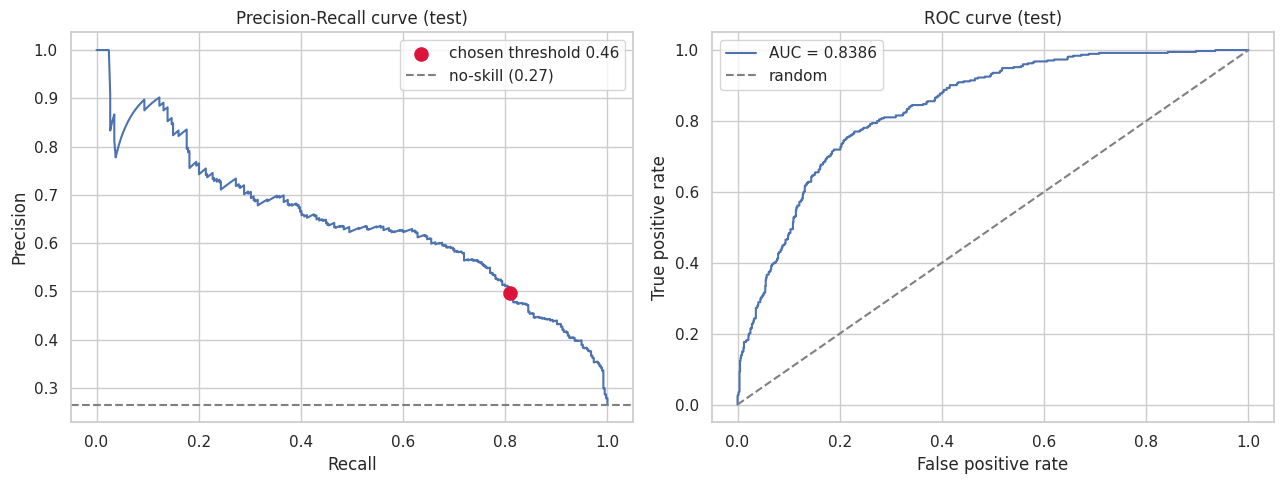

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

prec, rec, thr = precision_recall_curve(y_test, test_proba)
axes[0].plot(rec, prec)
idx = int(np.argmin(np.abs(thr - THRESHOLD)))
axes[0].scatter([rec[idx]], [prec[idx]], zorder=5, s=90, color="crimson",
                label=f"chosen threshold {THRESHOLD}")
axes[0].axhline(y_test.mean(), ls="--", c="grey", label=f"no-skill ({y_test.mean():.2f})")
axes[0].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall curve (test)")
axes[0].legend()

fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, test_proba):.4f}")
axes[1].plot([0, 1], [0, 1], ls="--", c="grey", label="random")
axes[1].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC curve (test)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Threshold selection

The threshold was chosen on the **validation** set by maximising F1, then
applied unchanged to test. Choosing it on test would leak the test set into a
tuning decision and inflate the reported score.

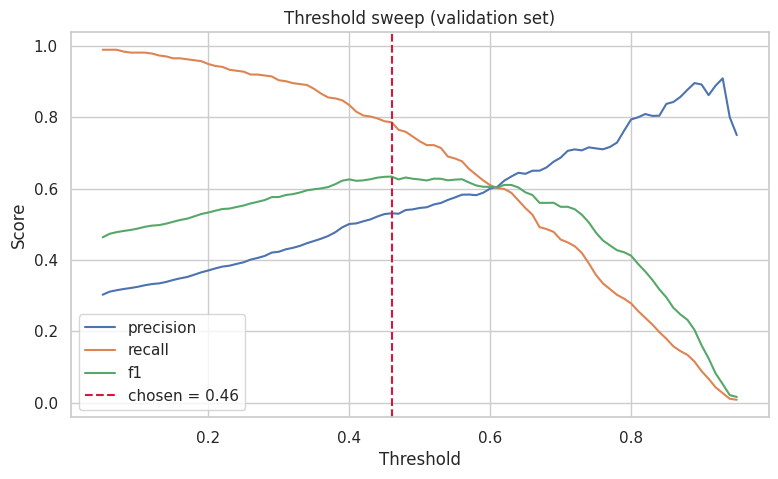

threshold    0.460000
precision    0.530686
recall       0.786096
f1           0.633621
Name: 41, dtype: float64

In [6]:
val_proba = model.predict_proba(X_val.drop(columns=DROP, errors="ignore"))[:, 1]

grid = np.arange(0.05, 0.96, 0.01)
sweep = pd.DataFrame({
    "threshold": grid,
    "precision": [precision_score(y_val, (val_proba >= t).astype(int), zero_division=0) for t in grid],
    "recall": [recall_score(y_val, (val_proba >= t).astype(int)) for t in grid],
    "f1": [f1_score(y_val, (val_proba >= t).astype(int)) for t in grid],
})

fig, ax = plt.subplots(figsize=(9, 5))
for col in ["precision", "recall", "f1"]:
    ax.plot(sweep["threshold"], sweep[col], label=col)
ax.axvline(THRESHOLD, ls="--", c="crimson", label=f"chosen = {THRESHOLD}")
ax.set(xlabel="Threshold", ylabel="Score", title="Threshold sweep (validation set)")
ax.legend()
plt.show()

sweep.loc[sweep["f1"].idxmax()]

### The business view

The F1-optimal threshold ignores money. This is the same trade priced in
dollars, using illustrative assumptions: a retention offer worth 30% off for
two months, a saved customer worth 12 months of revenue, and only 30% of
contacted churners actually persuadable.

These assumptions are invented - the robust finding is the **ratio**, not the
absolute figures.

In [7]:
mc = X_test["MonthlyCharges"].values
OFFER, VALUE, SAVE_RATE = mc * 0.30 * 2, mc * 12, 0.30

rows = []
for t in np.arange(0.10, 0.90, 0.05):
    flag = test_proba >= t
    tp = flag & (y_test.values == 1)
    rows.append({
        "threshold": round(t, 2),
        "flagged": int(flag.sum()),
        "true_churners": int(tp.sum()),
        "offer_cost": round(OFFER[flag].sum()),
        "revenue_saved": round(VALUE[tp].sum() * SAVE_RATE),
        "net_value": round(VALUE[tp].sum() * SAVE_RATE - OFFER[flag].sum()),
    })

budget = pd.DataFrame(rows)
print(f"cost of one wasted offer:    ${OFFER.mean():.2f}")
print(f"value of one saved customer: ${VALUE.mean():.2f}   ratio ~{VALUE.mean()/OFFER.mean():.0f}:1")
budget

cost of one wasted offer:    $38.40
value of one saved customer: $767.93   ratio ~20:1


,threshold,flagged,true_churners,offer_cost,revenue_saved,net_value
0,0.10,1099,370,46605,98178,51573
1,0.15,1025,364,43770,97020,53251
2,0.20,939,359,40582,95615,55033
3,0.25,875,350,38060,93726,55665
4,0.30,809,341,35187,91531,56344
5,0.35,747,330,32503,88322,55819
6,0.40,677,316,29492,84654,55162
7,0.45,619,303,26876,81184,54308
8,0.50,565,296,24522,79366,54844
9,0.55,500,280,22137,75885,53748


The economics push the threshold *lower* than F1 does, because a wasted
offer costs about $38 while a saved customer is worth about $768 - roughly
20:1. You can afford to be wrong about nineteen people to be right about one.

The constraint that actually bites in practice is **capacity**, not economics:
at a threshold of 0.15 you would contact over half the customer base. If humans
make those calls, the real question becomes "who are the top N?" - a ranking
problem, where precision at the top of the list matters more than recall.

The shipped model uses the F1 threshold, which needs no invented cost figures
to defend.

## 5. Fairness audit

`gender` was **excluded from the model input** - it measurably carried no
signal. It is still audited here: you audit on the attributes you refuse to
train on, otherwise you cannot show the exclusion worked.

*Disparate impact* is the ratio of the least- to most-flagged group. Below 0.8
is the conventional red flag.

In [8]:
audit_rows = []
for attr, groups in meta["fairness_audit"].items():
    for g, s in groups.items():
        if g.startswith("_"):
            continue
        audit_rows.append({
            "attribute": attr, "group": g, "n": s["n"],
            "actual_churn_rate": s["actual_churn_rate"],
            "flagged_rate": s["selection_rate"],
            "recall": s["recall"], "precision": s["precision"],
        })

audit = pd.DataFrame(audit_rows)
print("disparate impact:",
      {a: g.get("_disparate_impact") for a, g in meta["fairness_audit"].items()})
audit

disparate impact: {'gender': 0.9788, 'SeniorCitizen': 0.6015, 'Partner': 0.4703, 'Dependents': 0.409}


,attribute,group,n,actual_churn_rate,flagged_rate,recall,precision
0,gender,Female,681,0.2746,0.4391,0.7861,0.4916
1,gender,Male,726,0.2576,0.4298,0.8342,0.5000
2,SeniorCitizen,0,1175,0.2366,0.3915,0.7806,0.4717
3,SeniorCitizen,1,232,0.4138,0.6509,0.8958,0.5695
4,Partner,No,748,0.3209,0.5775,0.8833,0.4907
5,Partner,Yes,659,0.2033,0.2716,0.6791,0.5084
6,Dependents,No,993,0.3031,0.5257,0.8538,0.4923
7,Dependents,Yes,414,0.1763,0.2150,0.6301,0.5169


### Interpreting this honestly

**`gender`: disparate impact 0.979.** Near-perfect parity. Excluding it worked,
and there was no gender bias to remove in the first place - the cross-validated
ROC-AUC was *identical to four decimal places* with and without it. That is the
evidence for dropping it: it cost nothing.

**`SeniorCitizen`, `Partner`, `Dependents`: disparate impact 0.41-0.60**, all
below the 0.8 rule of thumb. This looks alarming and mostly is not, because a
different outcome across groups is not automatically unfair:

- Seniors are flagged 65% of the time - but they genuinely churn at 41.4% vs
  23.7% for non-seniors.
- Customers without dependents are flagged 53% vs 22% - and actually churn at
  30.3% vs 17.6%.

In every case the flagging gap moves in the same direction as the real churn
gap. The model is not inventing a disparity; it reflects one present in the data.

**Where it does warrant scrutiny:** recall is uneven. Customers with partners
get 0.679 recall versus 0.883 for those without - the model is meaningfully
worse at spotting churners among partnered customers. If retention offers are
allocated by this model, that group is systematically under-served. That is a
real finding, and the appropriate fix is group-aware threshold calibration
rather than dropping the feature.

**Also worth stating plainly:** none of this addresses *why* these groups churn
differently. The audit measures outcomes, not causes.

## 6. SHAP - what drives a prediction

`TreeExplainer` on the fitted forest. SHAP runs on the **transformed** matrix,
so feature names come from the pipeline's preprocessor, after one-hot encoding
and the engineered columns.

In [9]:
import shap

pre = model.named_steps["preprocessor"]
fe = model.named_steps["features"]
forest = model.named_steps["model"]

# Sample for speed - SHAP on tree ensembles is O(trees x depth x rows)
sample = X_test_m.sample(300, random_state=RANDOM_STATE)
X_trans = pre.transform(fe.transform(sample))
feature_names = pre.get_feature_names_out()

explainer = shap.TreeExplainer(forest)
shap_values = explainer.shap_values(X_trans)

# Binary classifier - keep the positive (churn) class
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

print("shap values:", shap_values.shape, "| features:", len(feature_names))

shap values: (300, 51) | features: 51


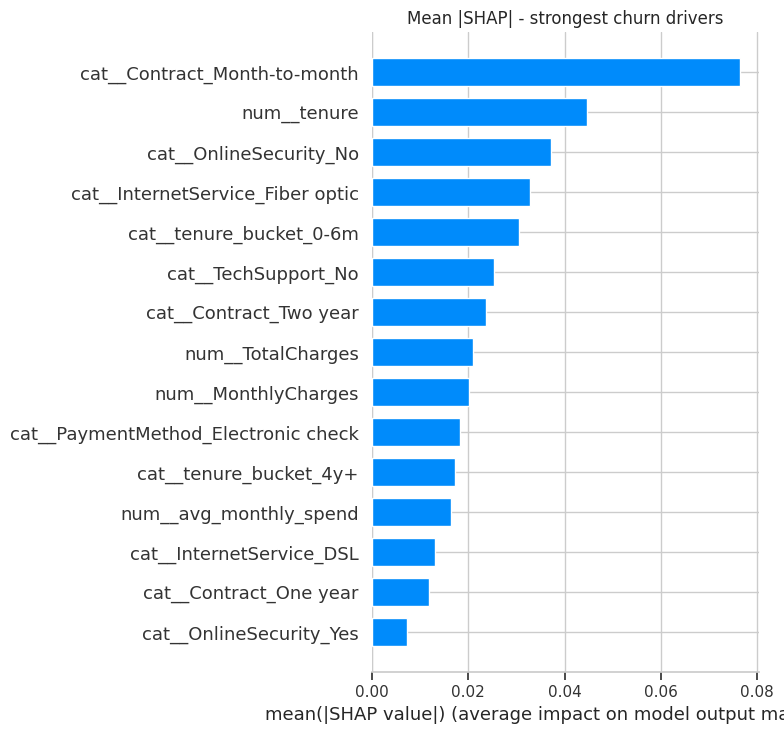

In [10]:
shap.summary_plot(shap_values, X_trans, feature_names=feature_names,
                  plot_type="bar", max_display=15, show=False)
plt.title("Mean |SHAP| - strongest churn drivers")
plt.tight_layout()
plt.show()

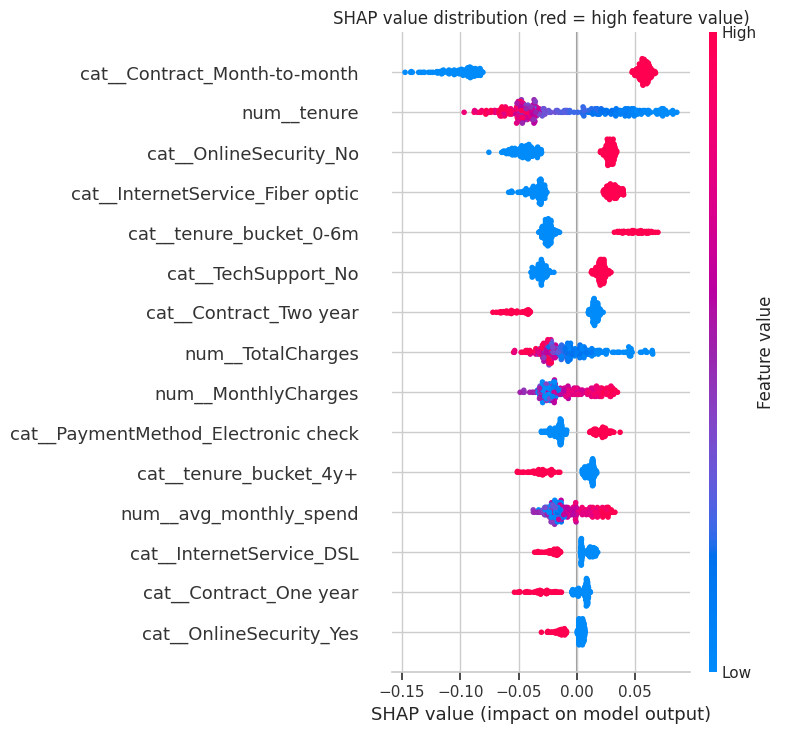

In [11]:
shap.summary_plot(shap_values, X_trans, feature_names=feature_names,
                  max_display=15, show=False)
plt.title("SHAP value distribution (red = high feature value)")
plt.tight_layout()
plt.show()

Read the beeswarm as: each dot is one customer, x-axis position is how much
that feature pushed their churn probability up (right) or down (left), and
colour is whether the feature value was high (red) or low (blue).

The expected pattern for this dataset: short tenure and month-to-month
contracts push strongly toward churn, two-year contracts push strongly away,
and electronic-check payment is a consistent positive signal. If the engineered
features (`num_addons`, `avg_monthly_spend`, `charges_delta`, `tenure_bucket`)
rank highly here, they earned their place.

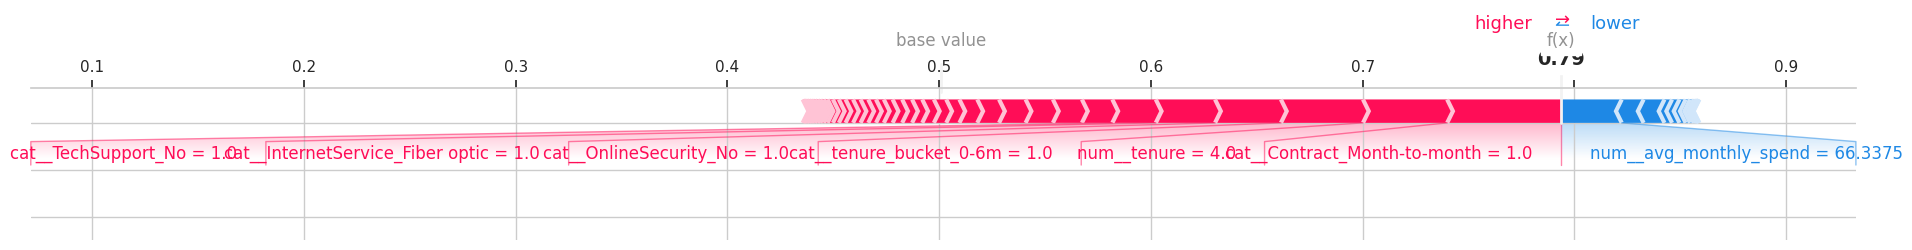

predicted churn probability: 0.7936


In [12]:
# One customer, explained end to end
i = 0
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = np.ravel(base_value)[-1]

shap.force_plot(base_value, shap_values[i], X_trans[i],
                feature_names=feature_names, matplotlib=True, show=False)
plt.tight_layout()
plt.show()

print("predicted churn probability:",
      round(float(model.predict_proba(sample.iloc[[i]])[0, 1]), 4))

## 7. Summary

| | Original | Current |
|---|---|---|
| Recall | 0.4947 | **0.8102** |
| Precision | 0.6401 | 0.4959 |
| F1 | 0.5581 | **0.6152** |
| ROC-AUC | 0.8145 | **0.8386** |
| Accuracy | 0.7918 | 0.7306 |
| Train - test gap | 0.2070 | **0.0399** |

What changed: the model now catches **81% of churners instead of 49%**, and the
overfitting gap essentially closed.

**The cost, stated plainly:** precision fell from 0.64 to 0.50, so half of all
flagged customers were never going to leave. And accuracy dropped to 0.7306 -
**marginally below the 0.7342 you would get by predicting that nobody ever
churns.**

That last point needs defending rather than hiding. Accuracy is the wrong
metric on an imbalanced problem: the do-nothing baseline scores 0.7342 while
being completely useless, since it has a ROC-AUC of 0.5 and never identifies a
single churner. This model scores 0.8386 ROC-AUC and finds 303 of 374 real
churners in the test set. Accuracy penalises it for 308 false positives that
are, in business terms, cheap.

If accuracy above baseline were a hard requirement, raising the threshold would
deliver it - at the cost of the recall that made the model worth deploying.